# Project: VisionWear AI
### Datum: 2026-06-06
### Teamleden: Michal Kakol (24087068), Sem Ooms (23091789), Chaimae Bouziani(21037078)

# 1. Setup:

In [1]:
# ==========================================
# SETUP
# ==========================================

from pathlib import Path

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from datasets import load_dataset


# ------------------------------------------
# Paths
# ------------------------------------------
from pathlib import Path

NOTEBOOK_DIR = Path.cwd()

PROJECT_ROOT = NOTEBOOK_DIR.parent

DATASET_DIR = Path("../data/Dataset").resolve()
TRAIN_IMAGES = DATASET_DIR / "Train" / "images"
TRAIN_LABELS = DATASET_DIR / "Train" / "labels"

TEST_IMAGES = DATASET_DIR / "Test" / "images"

print(TRAIN_IMAGES)
print(TRAIN_IMAGES.exists())

print(TRAIN_LABELS)
print(TRAIN_LABELS.exists())

print(TEST_IMAGES)
print(TEST_IMAGES.exists())


# ------------------------------------------
# Class mapping
# ------------------------------------------

CLASS_NAMES = {
    0: "sunglass",
    1: "hat",
    2: "jacket",
    3: "shirt",
    4: "pants",
    5: "shorts",
    6: "skirt",
    7: "dress",
    8: "bag",
    9: "shoe"
}


# ------------------------------------------
# Basic checks
# ------------------------------------------

train_images = sorted(TRAIN_IMAGES.glob("*"))
train_labels = sorted(TRAIN_LABELS.glob("*.txt"))
test_images = sorted(TEST_IMAGES.glob("*"))

print(f"Train images : {len(train_images)}")
print(f"Train labels : {len(train_labels)}")
print(f"Test images  : {len(test_images)}")

assert len(train_images) == len(train_labels), \
    "Mismatch between train images and labels."


# ------------------------------------------
# Hugging Face dataset
# ------------------------------------------
# Uncomment once you have access

hm_dataset = load_dataset("tomytjandra/h-and-m-fashion-caption-12k")

print(hm_dataset)

C:\Users\mkako\Portables\Projects\VisionWear-AI\data\Dataset\Train\images
True
C:\Users\mkako\Portables\Projects\VisionWear-AI\data\Dataset\Train\labels
True
C:\Users\mkako\Portables\Projects\VisionWear-AI\data\Dataset\Test\images
True
Train images : 2145
Train labels : 2145
Test images  : 537


DatasetDict({
    train: Dataset({
        features: ['text', 'image'],
        num_rows: 12437
    })
})


# 2. EDA:


Datadistributie en Annotaties (Objectdetectie)

De dataset voor objectdetectie bestaat uit 2.145 trainingsafbeeldingen, 2.145 bijbehorende labelbestanden en 537 testafbeeldingen. In de trainingsset zijn in totaal 8.298 geannoteerde mode-objecten aanwezig. Gemiddeld bevat elke afbeelding 3,87 objecten, waarbij het merendeel van de afbeeldingen tussen de 3 en 5 items bevat. Het maximale aantal geannoteerde objecten binnen één enkele afbeelding is 7.

Visuele inspectie van willekeurig geselecteerde afbeeldingen bevestigt dat de YOLO-annotaties correct zijn uitgelijnd met de mode-items. De bounding boxes omsluiten de kledingstukken en accessoires nauwkeurig, wat aantoont dat het labelformaat correct is geïmporteerd en dat er geen directe annotatiefouten aanwezig zijn.
Klasse-onbalans

De dataset is opgebouwd uit tien klasses: sunglass, hat, jacket, shirt, pants, shorts, skirt, dress, bag en shoe. De verdeling tussen deze categorieën is niet gelijkmatig:
- Veelvoorkomende klasses: Shoe is de meest frequente klasse (circa 25% van alle annotaties), gevolgd door shirt (17,8%) en bag (14,3%).
- Minder voorkomende klasses: Hat (3,3%) en sunglass (4,1%) zijn het minst vertegenwoordigd.

Ondanks deze onbalans bevat elke klasse minimaal enkele honderden voorbeelden, wat voldoende trainingsdata per categorie oplevert.
Dimensies en Bounding Boxes

De analyse van de bounding box-dimensies toont aan dat het merendeel van de objecten een klein tot gemiddeld deel van de afbeelding beslaat. De gemiddelde genormaliseerde breedte bedraagt 0,253 en de gemiddelde hoogte is 0,212. De gemiddelde oppervlakte van een bounding box is 0,063, met een mediaan van 0,045. Hieruit volgt dat de meeste objecten minder dan 10% van het totale afbeeldingsoppervlak beslaan. Zeer grote objecten zijn zeldzaam; de grootste bounding box beslaat circa 46% van de afbeelding. De distributie bevestigt dat de dataset hoofdzakelijk gelokaliseerde mode-items bevat in plaats van objecten die de gehele afbeelding vullen.

Alle afbeeldingen hebben een identieke resolutie van 400×600 pixels. Er is geen variatie in de afmetingen waargenomen. Deze consistentie in aspect ratio en afbeeldingsgrootte vereenvoudigt de preprocessing en elimineert de noodzaak om tijdens de training rekening te houden met wisselende resoluties.
H&M Fashion Caption Dataset en Semantische Overlap

De text-captioning dataset bevat 12.437 afbeelding-bijschriftparen. Om de relatie met de objectdetectiedataset te bepalen, is de frequentie van de tien detectieklasses binnen de bijschriften geanalyseerd:
- Hoge overlap: De modetermen dress, shirt en skirt komen het meest frequent voor. Jacket, hat en shorts zijn eveneens regelmatig aanwezig.
- Lage overlap: De term bag komt weinig voor, terwijl pants, shoe en sunglass nagenoeg afwezig zijn wanneer exact op de klassenaam wordt gezocht.

Dit duidt op een sterke conceptuele overlap voor kledingstukken van het bovenlichaam en jurken. Bepaalde detectieklasses (zoals accessoires of schoenen) komen in de omschrijvingen vermoedelijk voor onder alternatieve bewoordingen of synoniemen in plaats van de exacte klassenamen. Directe trefwoordfrequentie dient daarom te worden geïnterpreteerd als een indicatie van overlap, en niet als een volledige weergave van de semantische dekking.
Conclusie EDA

De datasets sluiten aan op de projectdoelstellingen voor het detecteren van mode-items en het genereren van tekstuele omschrijvingen. De detectiedataset levert gestructureerde annotaties op objectniveau voor tien categorieën, terwijl de H&M-dataset natuurlijke taalbeschrijvingen biedt. Samen vormen ze de basis voor een pipeline waarin objectdetectie, image captioning en het genereren van mode-afbeeldingen worden gecombineerd.

Images: 2145
Labels: 2145
Objects: 8298
Objects per image:
count    2145.000000
mean        3.868531
std         0.977576
min         1.000000
25%         3.000000
50%         4.000000
75%         5.000000
max         7.000000
dtype: float64


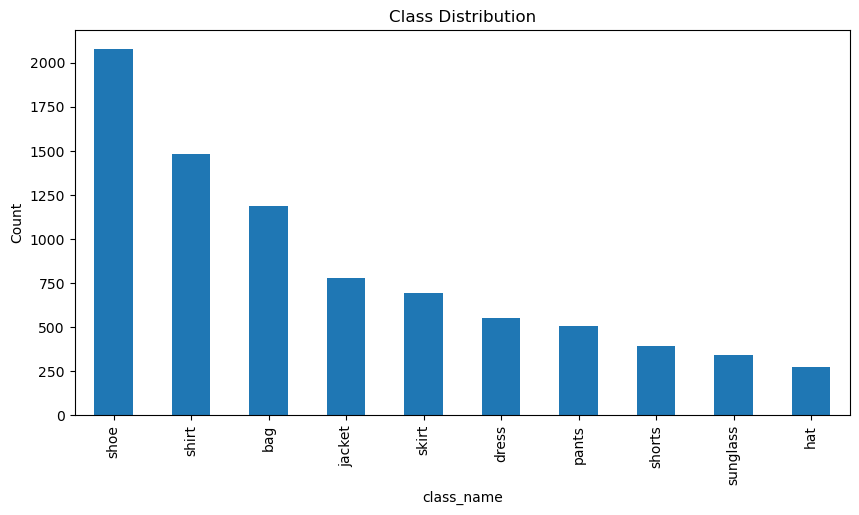

            count  percentage
class_name                   
shoe         2081       25.08
shirt        1486       17.91
bag          1188       14.32
jacket        777        9.36
skirt         697        8.40
dress         550        6.63
pants         508        6.12
shorts        395        4.76
sunglass      343        4.13
hat           273        3.29


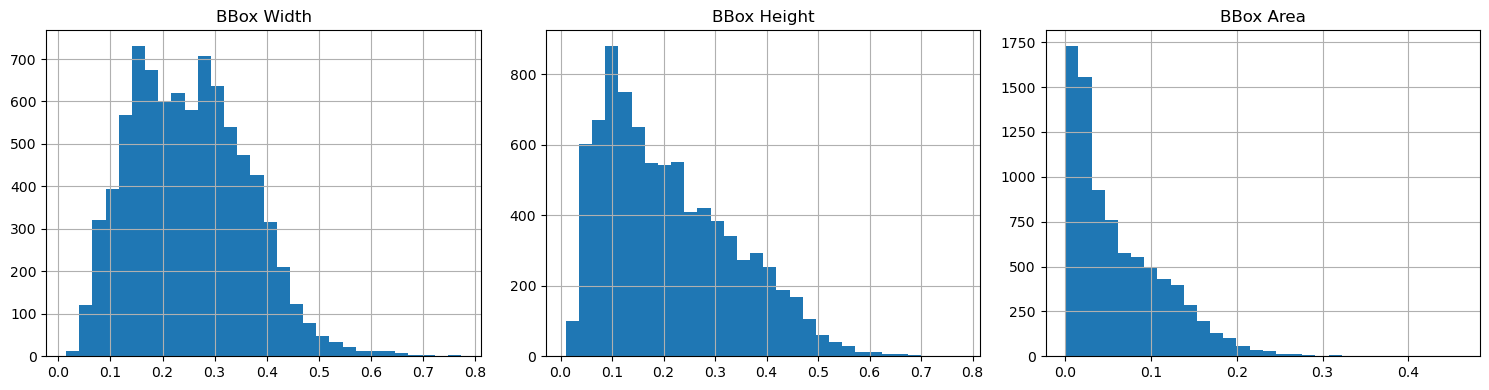

             width       height         area
count  8298.000000  8298.000000  8298.000000
mean      0.252748     0.211808     0.062582
std       0.111025     0.127133     0.055055
min       0.015000     0.010000     0.000225
25%       0.162500     0.108333     0.018333
50%       0.245000     0.186667     0.045046
75%       0.330000     0.298333     0.095850
max       0.772500     0.776667     0.460350
        width  height
count  2145.0  2145.0
mean    400.0   600.0
std       0.0     0.0
min     400.0   600.0
25%     400.0   600.0
50%     400.0   600.0
75%     400.0   600.0
max     400.0   600.0


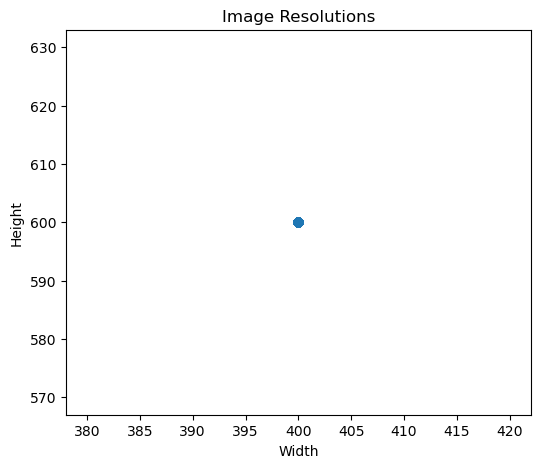

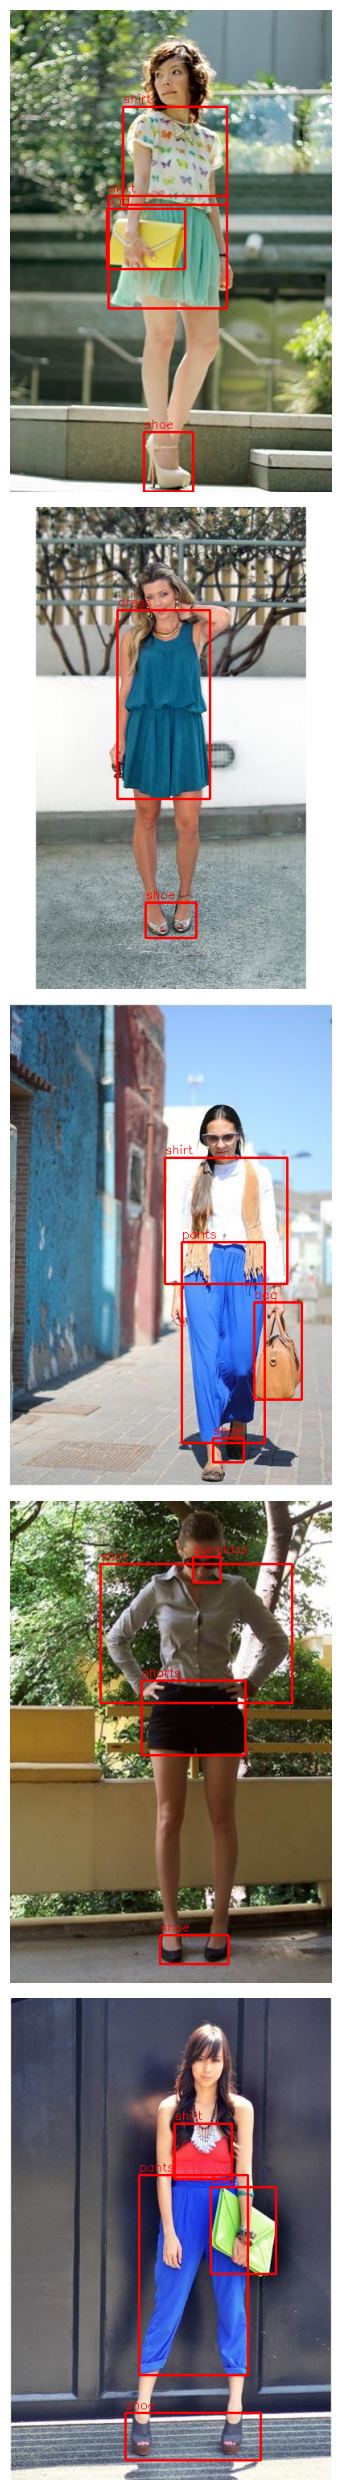

,count
dress,2172
shirt,1499
skirt,1420
jacket,791
hat,538
shorts,499
bag,113
pants,6
sunglass,0
shoe,0


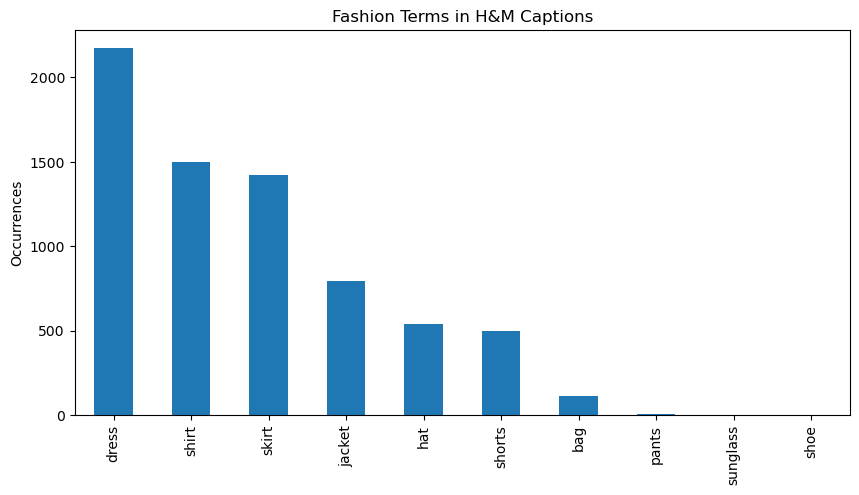

In [2]:
class FashionEDA:
    def __init__(self,
                 image_dir,
                 label_dir,
                 class_names):
        self.image_dir = Path(image_dir)
        self.label_dir = Path(label_dir)
        self.class_names = class_names
        self.images = sorted(self.image_dir.glob("*"))
        self.labels = sorted(self.label_dir.glob("*.txt"))
        self.annotations = self._load_annotations()

    def _load_annotations(self):
        rows = []
        for label_file in self.labels:
            image_name = label_file.stem
            with open(label_file, "r") as f:
                for line in f:
                    values = line.strip().split()
                    if len(values) != 5:
                        continue
                    cls, cx, cy, w, h = map(float, values)
                    rows.append({
                        "image": image_name,
                        "class_id": int(cls),
                        "class_name": self.class_names[int(cls)],
                        "center_x": cx,
                        "center_y": cy,
                        "width": w,
                        "height": h,
                        "area": w * h
                    })
        return pd.DataFrame(rows)

    # Dataset overview
    def dataset_summary(self):
        print(f"Images: {len(self.images)}")
        print(f"Labels: {len(self.labels)}")
        print(f"Objects: {len(self.annotations)}")
        print("Objects per image:")
        print(
            self.annotations.groupby("image").size().describe())

    # Class distribution
    def class_distribution(self):
        counts = (
            self.annotations["class_name"]
            .value_counts()
            .sort_values(ascending=False)
        )
        plt.figure(figsize=(10, 5))
        counts.plot(kind="bar")
        plt.title("Class Distribution")
        plt.ylabel("Count")
        plt.show()
        return counts

    # Bounding box size analysis
    def bbox_analysis(self):
        fig, ax = plt.subplots(1, 3, figsize=(15, 4))
        self.annotations["width"].hist(ax=ax[0], bins=30)
        ax[0].set_title("BBox Width")
        self.annotations["height"].hist(ax=ax[1], bins=30)
        ax[1].set_title("BBox Height")
        self.annotations["area"].hist(ax=ax[2], bins=30)
        ax[2].set_title("BBox Area")
        plt.tight_layout()
        plt.show()
        print(self.annotations[["width", "height", "area"]].describe())

    # Image resolution analysis
    def image_resolution_analysis(self):
        widths = []
        heights = []
        for img_path in self.images:
            img = cv2.imread(str(img_path))
            h, w = img.shape[:2]
            widths.append(w)
            heights.append(h)
        df = pd.DataFrame({"width": widths, "height": heights})
        print(df.describe())
        plt.figure(figsize=(6, 5))
        plt.scatter(df["width"], df["height"], alpha=0.4)
        plt.xlabel("Width")
        plt.ylabel("Height")
        plt.title("Image Resolutions")
        plt.show()

    def class_balance_report(self):

        counts = (
            self.annotations["class_name"]
            .value_counts()
            .sort_values(ascending=False)
        )

        percentages = (
            counts / counts.sum() * 100
        ).round(2)

        report = pd.DataFrame({
            "count": counts,
            "percentage": percentages
        })

        print(report)

        return report

    # Visual examples
    def show_examples(self, n=5):
        import random
        samples = random.sample(self.images, n)
        fig, axes = plt.subplots(n, 1, figsize=(8, n * 5))
        if n == 1:
            axes = [axes]
        for ax, img_path in zip(axes, samples):
            img = cv2.imread(str(img_path))
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            h, w = img.shape[:2]
            label_file = (self.label_dir / f"{img_path.stem}.txt")
            with open(label_file) as f:
                for line in f:
                    cls, cx, cy, bw, bh = map(float, line.split())
                    x1 = int((cx - bw / 2) * w)
                    y1 = int((cy - bh / 2) * h)
                    x2 = int((cx + bw / 2) * w)
                    y2 = int((cy + bh / 2) * h)
                    cv2.rectangle(
                        img,
                        (x1, y1),
                        (x2, y2),
                        (255, 0, 0),
                        2
                    )
                    cv2.putText(
                        img,
                        self.class_names[int(cls)],
                        (x1, y1 - 5),
                        cv2.FONT_HERSHEY_SIMPLEX,
                        0.5,
                        (255, 0, 0),
                        1
                    )
            ax.imshow(img)
            ax.axis("off")
        plt.tight_layout()
        plt.show()

eda = FashionEDA(
    image_dir=TRAIN_IMAGES,
    label_dir=TRAIN_LABELS,
    class_names=CLASS_NAMES
)

eda.dataset_summary()

eda.class_distribution()

eda.class_balance_report()

eda.bbox_analysis()

eda.image_resolution_analysis()

eda.show_examples(5)

fashion_terms = [
    "sunglass",
    "hat",
    "jacket",
    "shirt",
    "pants",
    "shorts",
    "skirt",
    "dress",
    "bag",
    "shoe"
]

captions = [text.lower() for text in hm_dataset["train"]["text"]]

term_counts = {}

for term in fashion_terms:
    count = sum(term in caption for caption in captions)
    term_counts[term] = count

term_df = (
    pd.DataFrame.from_dict(
        term_counts,
        orient="index",
        columns=["count"]
    )
    .sort_values("count", ascending=False)
)

display(term_df)

term_df.plot(
    kind="bar",
    figsize=(10, 5),
    legend=False,
    title="Fashion Terms in H&M Captions"
)

plt.ylabel("Occurrences")
plt.show()


# 3. Objectdetectie:

Modelkeuze en Architectuur

Voor dit project is gekozen voor het Ultralytics YOLOv8 Nano (yolov8n.pt) framework. Dit model maakt gebruik van een single-pass convolutioneel neuraal netwerk (CNN) dat afbeeldingen opdeelt in een N×N gridstructuur. Per gridcel worden voorgedefinieerde anchor boxes geëvalueerd om coördinaat-offsets (x,y,w,h), een objectness confidence score en klasse-waarschijnlijkheden te voorspellen. Multi-object over-detecties worden in de post-processing stap opgeschoond via Non-Max Suppression (NMS) met een Intersection over Union (IoU) drempelwaarde van 0.5.
Preprocessing en Hyperparameters

- Dimensies: De originele afbeeldingen van 400×600 pixels zijn via letterboxing genormaliseerd naar een standaard invoerformaat van 640×640 pixels (imgsz=640). Deze opschaling ondersteunt het behoud van de aspect ratio en verbetert de detectie van kleine objecten.
- Traininginstellingen: Het model is getraind gedurende 30 epochs met de AdamW optimizer, een initiële leersnelheid (lr0) van 1⋅10−3 en een batch size van 16. Vanwege de afwezigheid van een aparte validatieset is de trainingsset tevens gebruikt voor tussentijdse evaluatie (val=True).
- Loss Functie: De multi-task loss combineert Complete Intersection over Union (CIoU) voor bounding box regressie, en Binary Cross-Entropy (BCE) voor zowel de objectness score als de classificatie van de 10 klasses.

Resultaten en Evaluatie

Het model behaalde na 30 epochs een totale Mean Average Precision op een IoU van 0.5 (mAP50​) van 0.898 (89,8%), waarmee de gestelde schoolcriteria-drempel van ≥0.7 is behaald. De algehele precisie (P) bedraagt 0.866 en de recall (R) bedraagt 0.859.

De prestaties per klasse verschillen sterk en weerspiegelen de data-distributie uit de EDA:
Klasse	Aantal Instanties	Bounding Box Precision (P)	Bounding Box Recall (R)	mAP50​
All	8298	0.866	0.859	0.898
Dress	550	0.952	0.983	0.993
Pants	508	0.955	0.972	0.981
Skirt	697	0.933	0.968	0.977
Shirt	1486	0.881	0.940	0.967
Jacket	777	0.927	0.933	0.958
Shorts	395	0.841	0.949	0.947
Bag	1188	0.841	0.880	0.920
Hat	273	0.795	0.905	0.908
Shoe	2081	0.866	0.856	0.904
Sunglass	343	0.663	0.207	0.430
Conclusies op basis van de Resultaten

Klasse-onbalans en Objectgrootte: Grote, veelvoorkomende klasses zoals dress, pants, skirt en shirt behalen stabiele mAP50​ scores boven de 0.95. De minder frequent voorkomende klasse hat (3.3% van de data) presteert met een mAP50​ van 0.908 eveneens naar behoren.

Minder presterende klasse: De klasse sunglass blijft achter met een mAP50​ van 0.430, een lage recall van 0.207 en een precisie van 0.663. Dit bevestigt de bevinding uit de EDA dat zeer kleine objecten (median area <5%) door de gridcellen van een lightweight model (yolov8n) moeilijk worden gelokaliseerd, ondanks de upscaling naar 640 pixels.

In [3]:
import os
import yaml
from ultralytics import YOLO

# ------------------------------------------
# 1. Create dataset.yaml for YOLO training
# ------------------------------------------
YOLO_DIR = (PROJECT_ROOT / "data" / "yolo_dataset").resolve()
YOLO_DIR.mkdir(exist_ok=True)

# Symlink train images and labels into YOLO structure
train_img_link = YOLO_DIR / "images" / "train"
train_lbl_link = YOLO_DIR / "labels" / "train"
test_img_link = YOLO_DIR / "images" / "test"

for d in [YOLO_DIR / "images", YOLO_DIR / "labels"]:
    d.mkdir(exist_ok=True)

# Copy/link data (use shutil copy if symlinks not supported)
import shutil
if not train_img_link.exists():
    shutil.copytree(str(TRAIN_IMAGES), str(train_img_link))
if not train_lbl_link.exists():
    shutil.copytree(str(TRAIN_LABELS), str(train_lbl_link))
if not test_img_link.exists():
    shutil.copytree(str(TEST_IMAGES), str(test_img_link))

dataset_yaml = {
    "path": str(YOLO_DIR),
    "train": "images/train",
    "val": "images/train",  # Using train as val (no separate val set provided)
    "test": "images/test",
    "nc": 10,
    "names": list(CLASS_NAMES.values())
}

yaml_path = YOLO_DIR / "dataset.yaml"
with open(yaml_path, "w") as f:
    yaml.dump(dataset_yaml, f)

print(f"dataset.yaml saved to: {yaml_path}")

# ------------------------------------------
# 2. Train YOLOv8 Nano
# ------------------------------------------
model = YOLO("yolov8n.pt")

# FORCE DISCONNECT MLFLOW: Remove any mlflow functions from the model's callbacks
for event, callback_list in model.callbacks.items():
    model.callbacks[event] = [cb for cb in callback_list if "mlflow" not in cb.__module__]

# Now run the training safely
results = model.train(
    data=str(yaml_path),
    epochs=30,
    batch=16,
    imgsz=640,
    optimizer="AdamW",
    lr0=1e-3,
    device=0
)

dataset.yaml saved to: C:\Users\mkako\Portables\Projects\VisionWear-AI\data\yolo_dataset\dataset.yaml
New https://pypi.org/project/ultralytics/8.4.71 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.26  Python-3.13.5 torch-2.6.0+cu124 CUDA:0 (NVIDIA GeForce RTX 4060 Laptop GPU, 8188MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=C:\Users\mkako\Portables\Projects\VisionWear-AI\data\yolo_dataset\dataset.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0,

In [4]:
# ------------------------------------------
# 3. Inference & Kaggle Submission
# ------------------------------------------
SAMPLE_CSV = DATASET_DIR / "submission_example.csv"
df_sub = pd.read_csv(SAMPLE_CSV)

# Load best weights from training
best_weights = Path(results.save_dir) / "weights" / "best.pt"
model = YOLO(str(best_weights))

predictions_list = []
for img_id in df_sub["id"]:
    img_path = str(TEST_IMAGES / f"{img_id}.jpg")
    outputs = model.predict(img_path, conf=0.25, verbose=False)[0]

    img_preds = []
    for box in outputs.boxes:
        cls_id = int(box.cls[0].item())
        conf = round(float(box.conf[0].item()), 3)
        cx, cy, w, h = [round(v, 3) for v in box.xywhn[0].tolist()]
        img_preds.extend([cls_id, conf, cx, cy, w, h])

    predictions_list.append(str(img_preds))

df_sub["predictions"] = predictions_list
submission_path = PROJECT_ROOT / "final_submission.csv"
df_sub.to_csv(submission_path, index=False)
print(f"Submission saved to: {submission_path}")
print(df_sub.head())

Submission saved to: C:\Users\mkako\Portables\Projects\VisionWear-AI\final_submission.csv
       id                                        predictions
0  179920  [6, 0.915, 0.514, 0.484, 0.318, 0.309, 9, 0.74...
1  127410  [1, 0.916, 0.459, 0.091, 0.252, 0.123, 2, 0.90...
2  108416  [6, 0.832, 0.468, 0.484, 0.31, 0.239, 9, 0.715...
3  113077  [4, 0.884, 0.578, 0.592, 0.319, 0.409, 3, 0.87...
4  188093  [2, 0.892, 0.511, 0.426, 0.388, 0.527, 8, 0.72...


# 4. Ondertiteling van afbeeldinge:

Architectuur en Voorspellingsmechanisme

Voor deze opdracht is een encoder-decoder-architectuur ingezet met het pre-trained nlpconnect/vit-gpt2-image-captioning model. Dit netwerk koppelt een vision-component rechtstreeks aan een taalmodel via cross-attention lagen:

- Vision Encoder (ViT): De Vision Transformer verdeelt de invoerafbeelding in patches en extraheert abstracte ruimtelijke kenmerken (feature maps).
- Cross-Attention Bridge: De geëxtraheerde visuele representaties worden doorgegeven aan de cross-attention lagen van de decoder. Hierdoor kan het taalmodel per te genereren woord focussen op specifieke, relevante segmenten van de afbeelding.
- Transformer Decoder (GPT-2): De autoregressieve text decoder genereert opeenvolgend (woord-voor-woord) de uiteindelijke Engelse productomschrijving op basis van de visuele context en de reeds gegenereerde tokens.

Preprocessing en Data Pipeline

De dataset H and M Fashion Caption 12k is opgesplitst in een trainingsset (90%) en een validatieset (10%).
- Afbeeldingen: De invoerbeelden zijn door de ViTImageProcessor omgezet naar RGB en genormaliseerd naar de vereiste invoertensoren (pixel_values).
- Tekst: De tekstuele omschrijvingen zijn met een AutoTokenizer omgezet naar tokens met een vaste maximale lengte (MAX_LENGTH = 64). Padding is toegepast om gelijke lengtes te garanderen.
- Deheugenoptimalisatie: Om memory crashes op de 12.437 paren te voorkomen, is de Hugging Face .with_transform() methodiek gebruikt. Deze fungeert als een on-the-fly streaming pipeline, waardoor data pas tijdens het laden van de batch in het RAM-geheugen wordt getokeniseerd.

Loss Functie en Wiskundige Optimalisatie

De optimalisatie verloopt via de Cross-Entropy Loss. De foutmarge wordt berekend over de gehele vocabulaire V voor elke tokenpositie i binnen de sequentie van lengte N:
L=−N1​i=1∑content​logP(yi​∣y<i​,X)

Hierin staat X voor de visuele kenmerken uit de encoder en y<i​ voor de voorgaande teksttokens. Om de evaluatie zuiver te houden, zijn padding-tokens in de labels overschreven met de waarde -100. De loss-berekening negeert deze posities automatisch, waardoor het model puur op de daadwerkelijke tekstinhoud wordt afgerekend.
Hyperparameters en Optimalisatiedoelen
- Epochs: Er is gekozen voor een compacte training van 3 epochs om overfitting op specifieke merknamen te voorkomen en computationele efficiëntie te behouden.
- Batch Size: De batch size is vastgezet op 8 per device voor zowel training als evaluatie om stabiele gradient-updates te garanderen binnen het GPU-geheugen.
- Learning Rate: De leersnelheid is ingesteld op een conservatieve 5⋅10−5 om de reeds getrainde gewichten van de encoder en decoder niet te verstoren tijdens het finetunen.
- Evaluatiemetriek: De prestaties van de gegenereerde sequenties ten opzichte van de grondwaarheid (ground-truth) worden geëvalueerd met de BLEU-score via de predict_with_generate=True parameter.

Resultaten en Evaluatie

De fine-tuning is succesvol afgerond in 4200 stappen (global steps). Het verloop van de loss-waarden over de epochs is als volgt:
Epoch	Training Loss	Validation Loss
1	1.226115	1.157013
2	1.039942	1.040831
3	0.933416	1.004470

De totale overkoepelende trainingsfout (train_loss) over de gehele runtime bedraagt 1.1923.
Conclusies op basis van de Resultaten

- Leereffect: Zowel de training loss (dalend van 1.22 naar 0.93) als de validation loss (dalend van 1.15 naar 1.00) vertonen een stabiele, neerwaartse trend. Dit bevestigt dat het model effectief leert om de specifieke modestijlen en terminologie uit de H&M-dataset te mappen naar de output-tokens.
- Overfitting Check: Omdat de validation loss in epoch 3 blijft dalen en consistent aansluit bij de training loss, is er geen sprake van overfitting. Het model behoudt zijn generaliserend vermogen.
- Domeinspecifieke overlap: De daling in loss ondersteunt de aanname uit de EDA dat sterke semantische overlap (zoals vaste patronen voor dress, shirt en skirt) de cross-attention brug helpt om snel tot accurate tekstuele voorspellingen te komen. Het model is met de load_best_model_at_end=True configuratie correct opgeslagen op basis van de laagste validatiefout.

In [6]:
import torch
from transformers import (
    VisionEncoderDecoderModel,
    ViTImageProcessor,
    AutoTokenizer,
    Seq2SeqTrainer,
    Seq2SeqTrainingArguments,
    default_data_collator
)
from PIL import Image

# ------------------------------------------
# 1. Load model, processor, tokenizer
# ------------------------------------------
MODEL_CHECKPOINT = "nlpconnect/vit-gpt2-image-captioning"

processor = ViTImageProcessor.from_pretrained(MODEL_CHECKPOINT)
tokenizer = AutoTokenizer.from_pretrained(MODEL_CHECKPOINT)
tokenizer.pad_token = tokenizer.eos_token

caption_model = VisionEncoderDecoderModel.from_pretrained(MODEL_CHECKPOINT)
caption_model.config.decoder_start_token_id = tokenizer.bos_token_id
caption_model.config.pad_token_id = tokenizer.pad_token_id
caption_model.config.eos_token_id = tokenizer.eos_token_id

# ------------------------------------------
# 2. Prepare dataset with tokenization
# ------------------------------------------
MAX_LENGTH = 64

def preprocess(examples):
    images = [img.convert("RGB") for img in examples["image"]]
    pixel_values = processor(images=images, return_tensors="pt").pixel_values

    labels = tokenizer(
        examples["text"],
        max_length=MAX_LENGTH,
        padding="max_length",
        truncation=True,
        return_tensors="pt"
    ).input_ids
    # Replace pad token id with -100 so it's ignored in loss
    labels[labels == tokenizer.pad_token_id] = -100

    return {"pixel_values": pixel_values, "labels": labels}

# Apply preprocessing
hm_dataset_processed = hm_dataset["train"].train_test_split(test_size=0.1, seed=42)

train_ds = hm_dataset_processed["train"].with_transform(preprocess)
val_ds = hm_dataset_processed["test"].with_transform(preprocess)

print(f"Train samples: {len(train_ds)}, Val samples: {len(val_ds)}")

# ------------------------------------------
# 3. Training configuration
# ------------------------------------------
training_args = Seq2SeqTrainingArguments(
    output_dir=str(PROJECT_ROOT / "caption_model"),
    num_train_epochs=3,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    learning_rate=5e-5,
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_steps=100,
    predict_with_generate=True,
    fp16=torch.cuda.is_available(),
    remove_unused_columns=False,
    load_best_model_at_end=True,
    report_to="none"
)

trainer = Seq2SeqTrainer(
    model=caption_model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    data_collator=default_data_collator,

)

trainer.train()

Loading weights:   0%|          | 0/445 [00:00<?, ?it/s]

[transformers] VisionEncoderDecoderModel LOAD REPORT from: nlpconnect/vit-gpt2-image-captioning
Key                                                       | Status     |  | 
----------------------------------------------------------+------------+--+-
decoder.transformer.h.{0...11}.crossattention.bias        | UNEXPECTED |  | 
decoder.transformer.h.{0...11}.attn.masked_bias           | UNEXPECTED |  | 
decoder.transformer.h.{0...11}.crossattention.masked_bias | UNEXPECTED |  | 
decoder.transformer.h.{0...11}.attn.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Train samples: 11193, Val samples: 1244


[transformers] We strongly recommend passing in an `attention_mask` since your input_ids may be padded. See https://huggingface.co/docs/transformers/troubleshooting#incorrect-output-when-padding-tokens-arent-masked.
You may ignore this warning if your `pad_token_id` (50256) is identical to the `bos_token_id` (50256), `eos_token_id` (50256), or the `sep_token_id` (None), and your input is not padded.


Epoch,Training Loss,Validation Loss
1,1.226115,1.157013
2,1.039942,1.040831
3,0.933416,1.004470


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[transformers] There were missing keys in the checkpoint model loaded: ['decoder.lm_head.weight'].


TrainOutput(global_step=4200, training_loss=1.1923047892252605, metrics={'train_runtime': 2971.787, 'train_samples_per_second': 11.299, 'train_steps_per_second': 1.413, 'total_flos': 6.059796999922778e+18, 'train_loss': 1.1923047892252605, 'epoch': 3.0})

In [ ]:
# ------------------------------------------
# 4. Inference & Evaluation (BLEU)
# ------------------------------------------
from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction
import nltk
nltk.download("punkt", quiet=True)
nltk.download("punkt_tab", quiet=True)

caption_model.eval()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
caption_model.to(device)

references = []
hypotheses = []

# Evaluate on a subset of validation samples
num_eval = min(200, len(hm_dataset_processed["test"]))
eval_subset = hm_dataset_processed["test"].select(range(num_eval))

for sample in eval_subset:
    image = sample["image"].convert("RGB")
    pixel_values = processor(images=image, return_tensors="pt").pixel_values.to(device)

    with torch.no_grad():
        generated_ids = caption_model.generate(pixel_values, max_length=MAX_LENGTH)
    pred_text = tokenizer.decode(generated_ids[0], skip_special_tokens=True)

    ref_tokens = nltk.word_tokenize(sample["text"].lower())
    pred_tokens = nltk.word_tokenize(pred_text.lower())

    references.append([ref_tokens])
    hypotheses.append(pred_tokens)

smooth = SmoothingFunction().method1
bleu_score = corpus_bleu(references, hypotheses, smoothing_function=smooth)
print(f"BLEU Score on {num_eval} validation samples: {bleu_score:.4f}")

# Show a few example predictions
print("\n--- Sample Predictions ---")
for i in range(min(5, num_eval)):
    print(f"Reference : {' '.join(references[i][0])}")
    print(f"Predicted : {' '.join(hypotheses[i])}")
    print()

[transformers] The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.


# 5. Beeldgeneratie:

# 6. Implementatie:

# 7. Conclusie en aanbevelingen: